#### Próximas tarefas:
- importar meu inventário e mesclar com o do fábio (organizar colunas - tarefa minha, pode seguir sem isso e dps eu arrumo)
- Ver se tem que somar NMVOC e CH4 --> COV (n tenho ctz)
- Robinho tá fzndo o de SOx

#### Bibliotecas e caminhos

In [35]:
import pandas as pd
import geopandas as gpd
import xarray as xr
import glob, os

caminho_inv = r'C:\Users\glima\OneDrive\Documentos\Mestrado_GitHub\007.2026 - AnaliseInvCMAQ\inputs\inv_fabio\emission_total_light.csv'
caminho_br = r'C:\Users\glima\OneDrive\Documentos\Mestrado_GitHub\input_base\BR_UF_2025.shp'
caminho_cmaq = r'C:\Users\glima\OneDrive\Documentos\Mestrado_GitHub\007.2026 - AnaliseInvCMAQ\inputs\cmaq'

### Tratamento do inventário

In [ ]:
inv_fabio = pd.read_csv(caminho_inv)

C:\Users\glima\AppData\Local\Temp\ipykernel_37788\594227995.py:1: DtypeWarning: Columns (0: SNAP, 1: Technology, 2: Abatement, 3: Region) have mixed types. Specify dtype option on import or set low_memory=False.
  inv_fabio = pd.read_csv(caminho_inv)


In [71]:
print(inv_fabio.columns)

# NOx vou comparar com NO + NO2
# SOx vou comparar com SO2 --> Robinho ainda tá fazendo
# Os outros é comparação direta
poluentes = ['CO','PM25','PM10','SOx','NOx','NMVOC','CH4'] 
chaves = ['CPF_CNPJ', 'NOME_PESSOA', 'Latitude', 'Longitude', 'ANO', 'CD_MUN',
       'NM_MUN', 'SIGLA_UF', 'NFR', 'SETOR', 'SNAP', 'TIER', 'Technology',
       'Abatement', 'Fuel', 'Region']

#Transformando em GeoDataFrame para análises espaciais
inv_fabio_gdf = gpd.GeoDataFrame(
    inv_fabio[chaves + poluentes],
    geometry = gpd.points_from_xy(inv_fabio['Longitude'], inv_fabio['Latitude']),
    crs = 'EPSG:4326'
)


Index(['CPF_CNPJ', 'NOME_PESSOA', 'Latitude', 'Longitude', 'ANO', 'CD_MUN',
       'NM_MUN', 'SIGLA_UF', 'NFR', 'SETOR', 'SNAP', 'TIER', 'Technology',
       'Abatement', 'Fuel', 'Region', 'NOx', 'TSP', 'PM10', 'PM25', 'BC',
       'SOx', 'CO', 'NMVOC', 'NH3', 'CH4', 'Pb', 'Cd', 'Hg', 'As', 'Cr', 'Cu',
       'Ni', 'Se', 'Zn', 'PCB', 'PCDDF', 'HCB', 'Benzopyrene',
       'Benzobfluoranthene', 'Benzokfluoranthene', 'Indenopyrene'],
      dtype='str')


<Axes: >

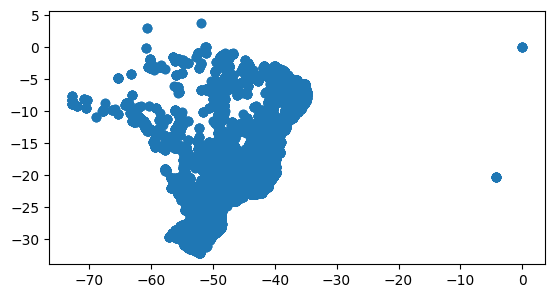

In [72]:
#Visualização das indústrias do inventário
inv_fabio_gdf.plot()

In [73]:
# Inventário contem pontos meio fora, vou fazer um buffer no limite do Brasil para filtrar tais pontos
brasil = gpd.read_file(caminho_br)
limite_brasil_buffer = brasil.union_all().buffer(0.1)

#filtrando pontos dentro do buffer (retirando pontos claramente errados)
mask = inv_fabio_gdf.intersects(limite_brasil_buffer)
fora = inv_fabio_gdf.loc[~mask]
inv_fabio_gdf_br = inv_fabio_gdf.loc[mask].reset_index(drop=True)

<Axes: >

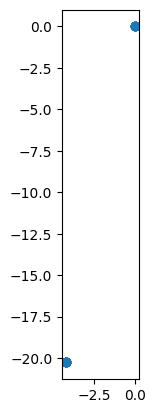

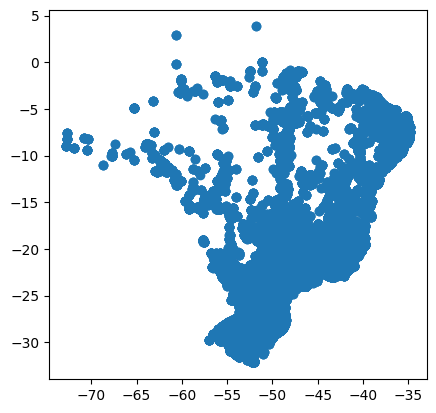

In [74]:
#visualização dos resultados do filtro
fora.plot()
inv_fabio_gdf_br.plot()

#### Trabalhando com os dados do CMAQ

#### Importação dos datasets

In [67]:
dataset = {}

for arquivo in glob.glob(os.path.join(caminho_cmaq, '*.nc')):
    nome = os.path.basename(arquivo)          # ex: BRAIN_SURFACE_NO2_2023...
    poluente = nome.split('_')[2]             # pega "NO", "NO2", "CO"...
    dataset[poluente] = xr.open_dataset(arquivo)

In [68]:
print(dataset.keys())

dict_keys(['CO', 'NO2', 'NO', 'O3', 'PM10', 'PM25'])
